<a href="https://colab.research.google.com/github/PrashAI/myprojectr/blob/master/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
claimants = pd.read_csv('/content/claimants.csv')
claimants

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [ ]:
claimants.isna().sum()

,0
CASENUM,0
ATTORNEY,0
CLMSEX,12
CLMINSUR,41
SEATBELT,48
CLMAGE,189
LOSS,0


In [ ]:
claimants.describe()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
count,1340.000000,1340.000000,1328.000000,1299.000000,1292.000000,1151.000000,1340.000000
mean,11202.001493,0.488806,0.558735,0.907621,0.017028,28.414422,3.806307
std,9512.750796,0.500061,0.496725,0.289671,0.129425,20.304451,10.636903
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4177.000000,0.000000,0.000000,1.000000,0.000000,9.000000,0.400000
50%,8756.500000,0.000000,1.000000,1.000000,0.000000,30.000000,1.069500
75%,15702.500000,1.000000,1.000000,1.000000,0.000000,43.000000,3.781500
max,34153.000000,1.000000,1.000000,1.000000,1.000000,95.000000,173.604000


<Axes: xlabel='ATTORNEY', ylabel='CLMAGE'>

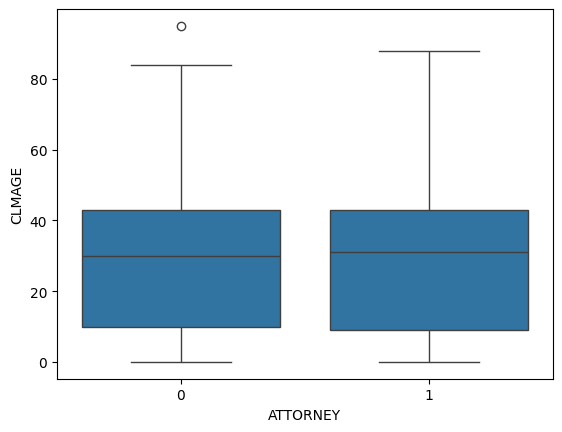

In [ ]:
sns.boxplot(x='ATTORNEY', y='CLMAGE', data= claimants)

<Axes: xlabel='ATTORNEY', ylabel='count'>

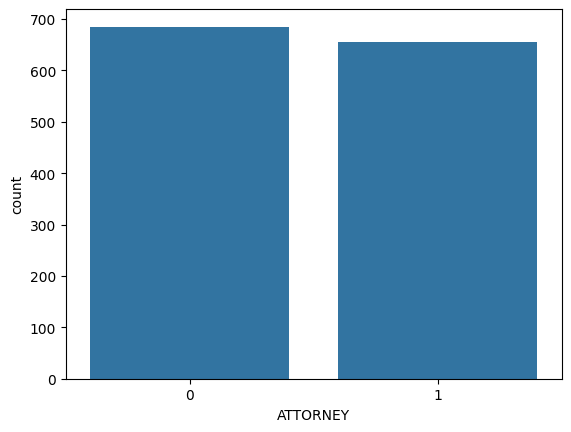

In [ ]:
sns.countplot(x= 'ATTORNEY', data = claimants)

In [ ]:
pd.crosstab(claimants.ATTORNEY, claimants.CLMINSUR)

CLMINSUR,0.0,1.0
ATTORNEY,,
0,76,585
1,44,594


<Axes: xlabel='ATTORNEY'>

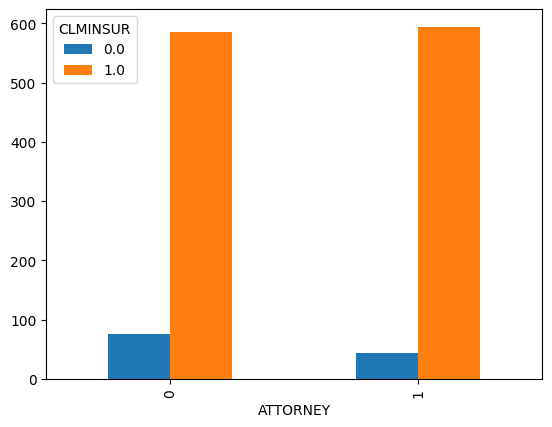

In [ ]:
pd.crosstab(claimants.ATTORNEY, claimants.CLMINSUR).plot(kind = 'bar')

<Axes: xlabel='SEATBELT', ylabel='count'>

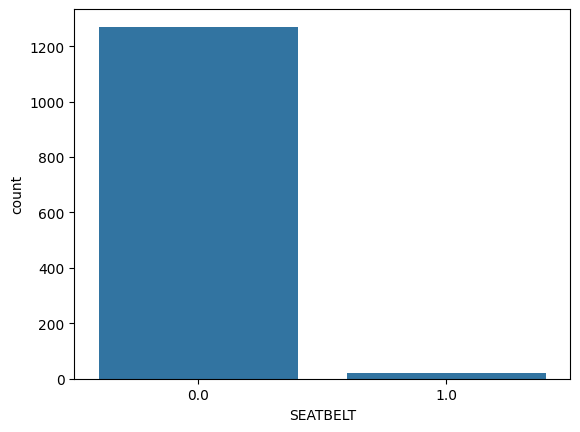

In [ ]:
sns.countplot(x= 'SEATBELT', data = claimants)

<Axes: xlabel='CLMINSUR', ylabel='count'>

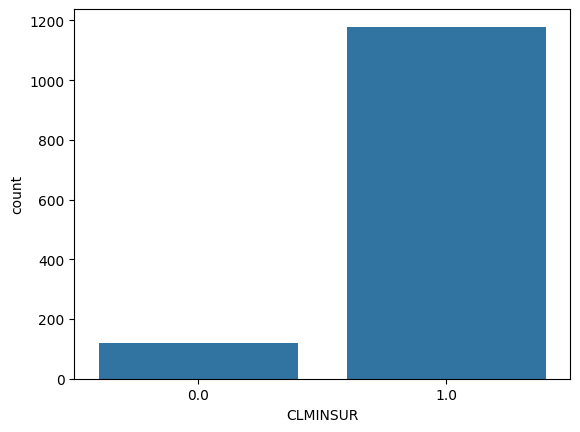

In [ ]:
sns.countplot(x= 'CLMINSUR', data = claimants)

<Axes: xlabel='SEATBELT'>

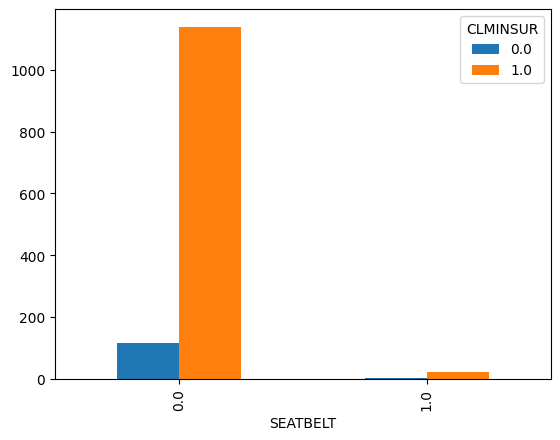

In [ ]:
pd.crosstab(claimants.SEATBELT, claimants.CLMINSUR).plot(kind = 'bar')

<Axes: xlabel='CLMSEX', ylabel='count'>

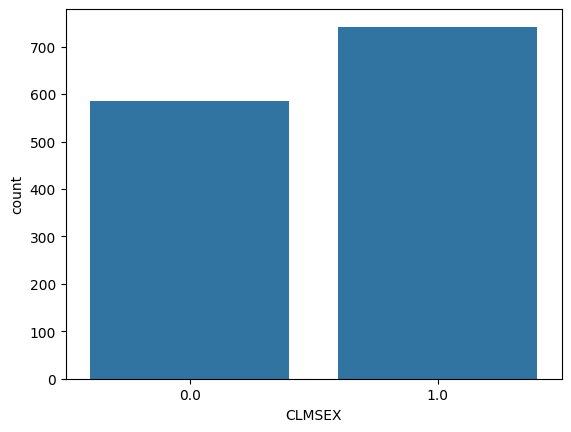

In [ ]:
sns.countplot(x= 'CLMSEX', data = claimants)

<Axes: xlabel='CLMSEX'>

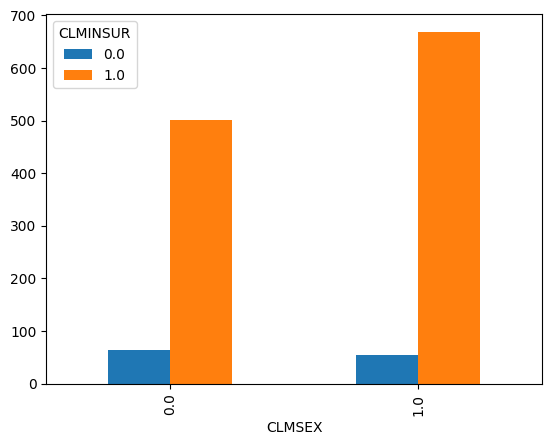

In [ ]:
pd.crosstab(claimants.CLMSEX, claimants.CLMINSUR).plot(kind = 'bar')

In [ ]:
claimants['CLMSEX'].fillna(1, inplace = True)
claimants['CLMINSUR'].fillna(1, inplace = True)
claimants['SEATBELT'].fillna(1, inplace = True)
claimants['CLMAGE'].fillna(1, inplace = True)

<ipython-input-20-ffee44e5ec99>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  claimants['CLMSEX'].fillna(1, inplace = True)
<ipython-input-20-ffee44e5ec99>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [ ]:
claimants.isna().sum()

,0
CASENUM,0
ATTORNEY,0
CLMSEX,0
CLMINSUR,0
SEATBELT,0
CLMAGE,0
LOSS,0


**Model Buillding with Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
claimants.shape

(1340, 7)

In [ ]:
X = claimants.iloc[:,[1,2,3,4,5]]
Y = claimants.iloc[:,0]
classifier = LogisticRegression()
classifier.fit(X,Y)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
classifier.coef_

array([[-0.52156213, -0.61692265, -0.1219373 , -0.0596018 ,  0.11547183],
       [ 0.50930224,  0.4390444 , -0.81751057, -0.04675842,  0.06785467],
       [-0.44087949,  0.3912759 ,  0.09657642, -0.05526895,  0.07157363],
       ...,
       [ 0.2898942 ,  0.18580292, -0.23077593, -0.06543498,  0.1019933 ],
       [-0.29693553,  0.61152683, -0.57933408, -0.03730973,  0.0089065 ],
       [ 0.34265305,  0.24786908, -0.12403664, -0.06192056,  0.08718685]])

In [ ]:
classifier.predict_proba (X)

array([[1.98935099e-03, 1.81321670e-04, 4.78058067e-04, ...,
        7.75638849e-04, 1.99643152e-05, 5.31129022e-04],
       [4.87589216e-04, 3.29557524e-03, 1.13996361e-03, ...,
        1.63914528e-03, 1.00066422e-03, 1.81736023e-03],
       [3.20628301e-04, 6.98285477e-04, 6.02177719e-04, ...,
        5.16149374e-04, 4.87227657e-04, 7.25429049e-04],
       ...,
       [8.73266191e-04, 1.08308585e-03, 1.01046943e-03, ...,
        1.98387938e-03, 1.21015399e-04, 1.79331907e-03],
       [4.71676105e-04, 1.83071614e-03, 1.57793172e-03, ...,
        8.05995765e-04, 2.24456090e-03, 9.82985362e-04],
       [7.51263159e-04, 1.43030006e-03, 1.29048018e-03, ...,
        1.92683084e-03, 2.71651857e-04, 1.99002773e-03]])

In [ ]:
y_pred = classifier.predict(X)
claimants['y_pred'] = y_pred
claimants

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,y_pred
0,5,0,0.0,1.0,0.0,50.0,34.940,6409
1,3,1,1.0,0.0,0.0,18.0,0.891,30903
2,66,1,0.0,1.0,0.0,5.0,0.330,376
3,70,0,0.0,1.0,1.0,31.0,0.037,590
4,96,1,0.0,1.0,0.0,30.0,0.038,5108
...,...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,1.0,0.576,31388
1336,34110,0,1.0,1.0,0.0,46.0,3.705,700
1337,34113,1,1.0,1.0,0.0,39.0,0.099,8400
1338,34145,0,1.0,0.0,0.0,8.0,3.177,31056


In [ ]:
y_preb = pd.DataFrame(classifier.predict_log_proba(X.iloc[:,:]))
new_df = pd.concat([claimants, y_pred],axis=1)
new_df

TypeError: cannot concatenate object of type '<class 'numpy.ndarray'>'; only Series and DataFrame objs are valid